# Section 15: Weight inits and investigations

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import requests
import io
import copy
import scipy.stats as stats

## Explanation of weight matrix sizes

In [2]:
model_1 = nn.Sequential(
    nn.Linear(10, 14),
    nn.Linear(14, 19),
    nn.Linear(19, 8)
)

model_1

Sequential(
  (0): Linear(in_features=10, out_features=14, bias=True)
  (1): Linear(in_features=14, out_features=19, bias=True)
  (2): Linear(in_features=19, out_features=8, bias=True)
)

In [3]:
for i in range(len(model_1)):
    print(model_1[i].weight.shape)

torch.Size([14, 10])
torch.Size([19, 14])
torch.Size([8, 19])


In [4]:
model_2 = nn.Sequential(
    nn.Linear(10, 14),
    nn.Linear(14, 9),
    nn.Linear(19, 8)
)

model_2

Sequential(
  (0): Linear(in_features=10, out_features=14, bias=True)
  (1): Linear(in_features=14, out_features=9, bias=True)
  (2): Linear(in_features=19, out_features=8, bias=True)
)

In [5]:
for i in range(len(model_2)):
    print(model_2[i].weight.shape)

torch.Size([14, 10])
torch.Size([9, 14])
torch.Size([8, 19])


In [6]:
n_samples = 5
n_features = 10
fake_data = torch.randn(n_samples, n_features)

In [7]:
model_1(fake_data).shape

torch.Size([5, 8])

In [8]:
# Will not work!
# model_2(fake_data).shape

## A surprising demo of weight initializations

In [9]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

X = data[:, 1:]
y = data[:, 0]
X_norm = X / np.max(X)

X_tensor = torch.tensor(X_norm).float()
y_tensor = torch.tensor(y).long()

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=.1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [10]:
def create_model():
    class MnistNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input = nn.Linear(784, 64)
            self.fc1 = nn.Linear(64, 32)
            self.fc2 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 10)
            
        def forward(self, x_param):
            x_local = self.input(x_param)
            x_local = F.relu(x_local)
            x_local = self.fc1(x_local)
            x_local = F.relu(x_local)
            x_local = self.fc2(x_local)
            x_local = F.relu(x_local)

            return  self.output(x_local)
    
    mnist_net_local = MnistNet()
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(mnist_net_local.parameters(), lr=.01)
    
    return mnist_net_local, loss_function_local, optimizer_local

In [11]:
temp_net = create_model()[0]

print(temp_net)
print("\n\nWeights for layer fc1:")
print(temp_net.fc1.weight)

MnistNet(
  (input): Linear(in_features=784, out_features=64, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=10, bias=True)
)


Weights for layer fc1:
Parameter containing:
tensor([[-0.0437,  0.0459, -0.0657,  ..., -0.0118,  0.1170,  0.0459],
        [-0.0314,  0.0793, -0.0614,  ...,  0.0853,  0.0275,  0.0367],
        [ 0.1053,  0.1005, -0.0770,  ..., -0.0743, -0.0310,  0.0112],
        ...,
        [ 0.0287, -0.0297,  0.0519,  ...,  0.1238,  0.0571,  0.0090],
        [ 0.0333, -0.0077, -0.0040,  ...,  0.0990,  0.1047, -0.0430],
        [-0.0487,  0.0815, -0.1025,  ..., -0.0386, -0.1242, -0.0185]],
       requires_grad=True)


In [12]:
def train_model(mnist_net_local, loss_function_local, optimizer_local):
    train_accuracies_local = []
    test_accuracies_local = []
     
    for epoch in range(10):
        batch_accuracies = []
         
        mnist_net_local.train()
         
        for X_local, y_local in train_loader:
            y_pred = mnist_net_local(X_local)
            loss = loss_function_local(y_pred, y_local)
               
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        mnist_net_local.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = mnist_net_local(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local

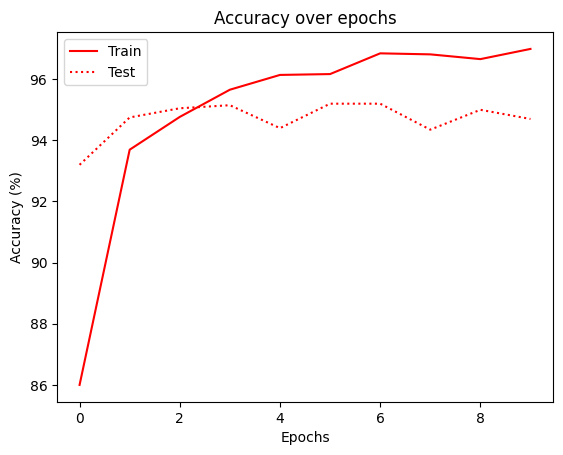

In [13]:
net_base, loss_function, optimizer = create_model()
train_acc_base, test_acc_base = train_model(net_base, loss_function, optimizer)

plt.plot(range(len(train_acc_base)), train_acc_base, 'r', label='Train')
plt.plot(range(len(test_acc_base)), test_acc_base, 'r', label='Test', linestyle='dotted')
plt.legend()
plt.title("Accuracy over epochs")
plt.xlabel('Epochs')
plt.ylabel("Accuracy (%)")
plt.show()

In [14]:
net_zero, loss_function, optimizer = create_model()
net_zero.fc1.weight.data = torch.zeros_like(net_zero.fc1.weight)

net_zero.fc1.weight

Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)

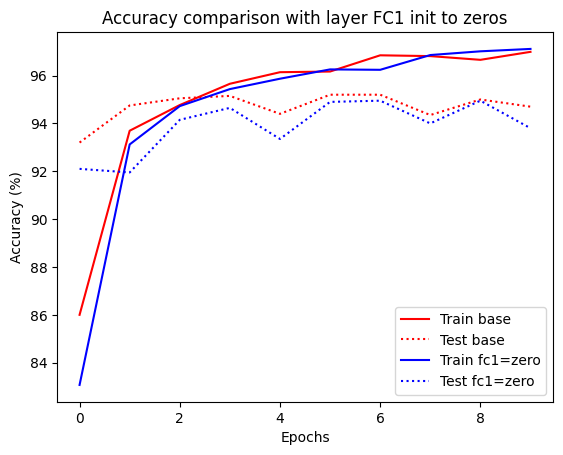

In [15]:
train_acc_zero, test_acc_zero = train_model(net_zero, loss_function, optimizer)

plt.plot(range(len(train_acc_base)), train_acc_base, 'r', label="Train base")
plt.plot(range(len(test_acc_base)), test_acc_base, 'r', label="Test base", linestyle='dotted')
plt.plot(range(len(train_acc_zero)), train_acc_zero, 'b', label="Train fc1=zero")
plt.plot(range(len(test_acc_zero)), test_acc_zero, 'b', label="Test fc1=zero", linestyle='dotted')
plt.legend()
plt.title("Accuracy comparison with layer FC1 init to zeros")
plt.xlabel('Epochs')
plt.ylabel("Accuracy (%)")
plt.show()

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.9561,  0.1944,  0.0289,  ...,  0.5542, -0.2500,  0.1589],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.6652, -0.8207,  0.0842,  ..., -0.9022,  0.5334, -0.0453],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])


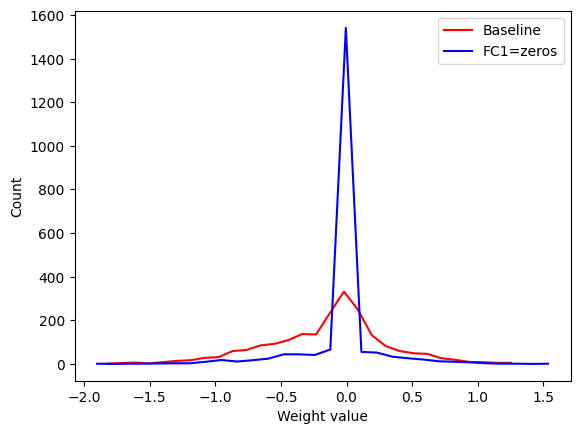

In [16]:
print(net_zero.fc1.weight.data)

y, x = np.histogram(net_base.fc1.weight.data.flatten(), 30)

plt.plot((x[1:] + x[:-1]) / 2, y, 'r', label='Baseline')

y, x = np.histogram(net_zero.fc1.weight.data.flatten(), 30)

plt.plot((x[1:] + x[:-1]) / 2, y, 'b', label='FC1=zeros')

plt.legend()
plt.xlabel("Weight value")
plt.ylabel('Count')
plt.show()

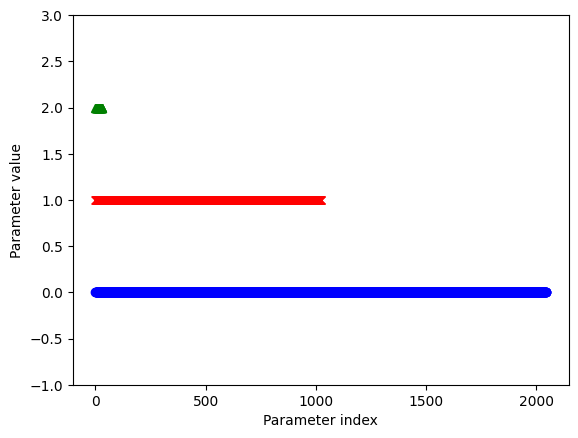

In [17]:
net_all_zero, loss_function, optimizer = create_model()

for p in net_all_zero.named_parameters():
    p[1].data = torch.zeros_like(p[1].data)
    
plt.plot(0 + net_all_zero.fc1.weight.data.flatten(), 'bo')
plt.plot(1 + net_all_zero.fc2.weight.data.flatten(), 'rx')
plt.plot(2 + net_all_zero.fc1.bias.data.flatten(), 'g^')
plt.xlabel("Parameter index")
plt.ylim([-1, 3])
plt.ylabel("Parameter value")
plt.show()

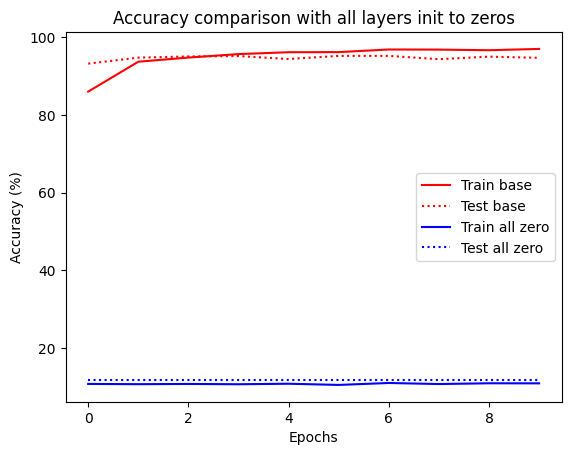

In [18]:
train_acc_all_zero, test_acc_all_zero = train_model(net_all_zero, loss_function, optimizer)

plt.plot(range(len(train_acc_base)), train_acc_base, 'r', label="Train base")
plt.plot(range(len(test_acc_base)), test_acc_base, 'r', label="Test base", linestyle='dotted')
plt.plot(range(len(train_acc_all_zero)), train_acc_all_zero, 'b', label="Train all zero")
plt.plot(range(len(test_acc_all_zero)), test_acc_all_zero, 'b', label="Test all zero", linestyle='dotted')
plt.legend()
plt.title("Accuracy comparison with all layers init to zeros")
plt.xlabel('Epochs')
plt.ylabel("Accuracy (%)")
plt.show()

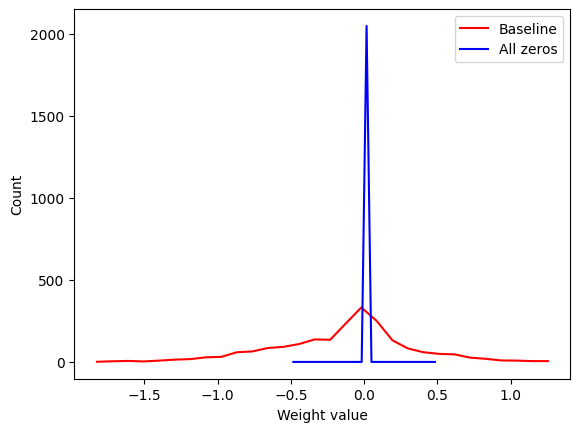

In [19]:
y, x = np.histogram(net_base.fc1.weight.data.flatten(), 30)

plt.plot((x[1:] + x[:-1]) / 2, y, 'r', label='Baseline')

y, x = np.histogram(net_all_zero.fc1.weight.data.flatten(), 30)

plt.plot((x[1:] + x[:-1]) / 2, y, 'b', label="All zeros")

plt.legend()
plt.xlabel("Weight value")
plt.ylabel('Count')
plt.show()

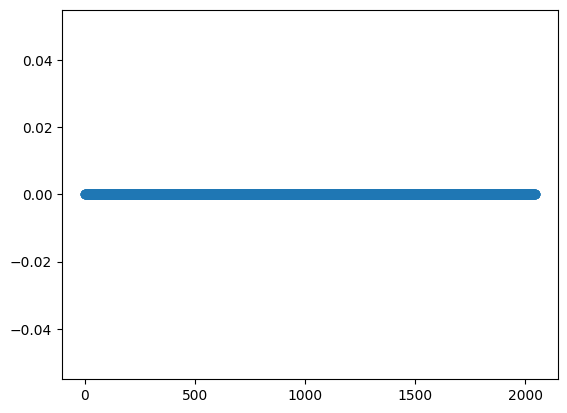

In [20]:
plt.plot(net_all_zero.fc1.weight.data.flatten(), 'o')
plt.show()

In [21]:
net_all_one, loss_function, optimizer = create_model()

for p in net_all_one.named_parameters():
    p[1].data = torch.zeros_like(p[1].data) + 1

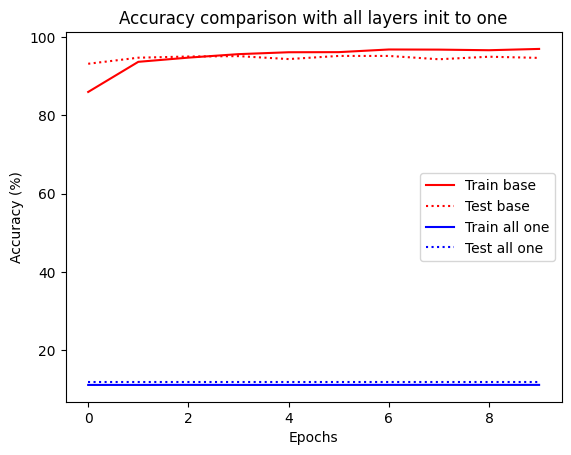

In [22]:
train_acc_all_one, test_acc_all_one = train_model(net_all_zero, loss_function, optimizer)

plt.plot(range(len(train_acc_base)), train_acc_base, 'r', label="Train base")
plt.plot(range(len(test_acc_base)), test_acc_base, 'r', label="Test base", linestyle='dotted')
plt.plot(range(len(train_acc_all_one)), train_acc_all_one, 'b', label="Train all one")
plt.plot(range(len(test_acc_all_one)), test_acc_all_one, 'b', label="Test all one", linestyle='dotted')
plt.legend()
plt.title("Accuracy comparison with all layers init to one")
plt.xlabel('Epochs')
plt.ylabel("Accuracy (%)")
plt.show()

## CodeChallenge: Weight variance inits

In [23]:
std_deviations = np.geomspace(.0001, 10, 25)

In [24]:
final_3_test_acc = []
all_params = []

for std_deviation in std_deviations:
    net_normal, loss_function, optimizer = create_model()
    
    for p in net_normal.named_parameters():
        p[1].data = torch.randn_like(p[1].data) * std_deviation
        
    train_acc_normal, test_acc_normal = train_model(net_normal, loss_function, optimizer)
    
    final_3_test_acc.append(np.mean(test_acc_normal[-3:]))
    
    params = np.array([])
    
    for p in net_normal.named_parameters():
        params = np.concatenate((params, p[1].data.numpy().flatten()), axis=0)
    
    all_params.append(params)
    
all_params = np.stack(all_params)

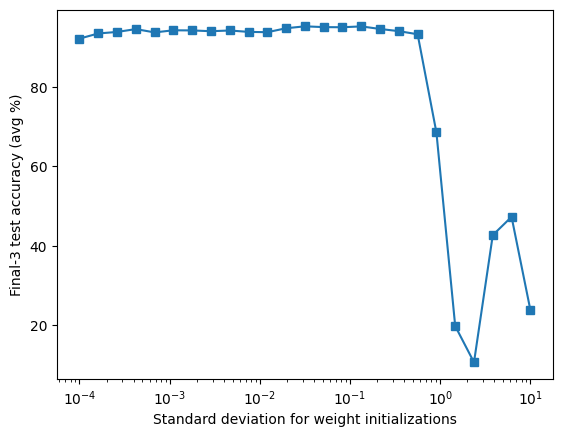

In [25]:
plt.plot(std_deviations, final_3_test_acc, 's-')
plt.xlabel("Standard deviation for weight initializations")
plt.xscale('log')
plt.ylabel("Final-3 test accuracy (avg %)")
plt.show()

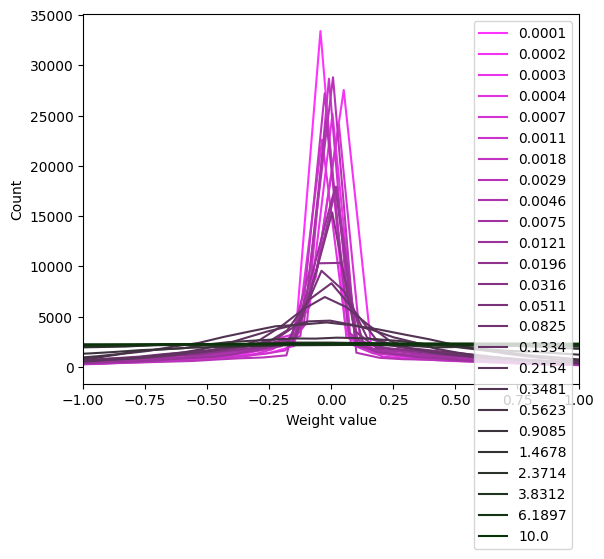

In [26]:
for i, all_weight in enumerate(all_params):
    y, x = np.histogram(all_weight, 80)
    color = 1 - i / len(std_deviations)

    plt.plot((x[1:] + x[:-1]) / 2, y, color=[color, .2, color], label=round(std_deviations[i], 4))

plt.legend()
plt.xlabel("Weight value")
plt.xlim([-1, 1])
plt.ylabel('Count')
plt.show()

## Xavier and Kaiming initializations

In [27]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input = nn.Linear(100, 100)
        self.fc1 = nn.Linear(100, 100)
        self.fc2 = nn.Linear(100, 100)
        self.fc3 = nn.Linear(100, 100)
        self.output = nn.Linear(100, 2)
        
    def forward(self, x_param):
        x_local = F.relu(self.input(x_param))
        x_local = F.relu(self.fc1(x_local))
        x_local = F.relu(self.fc2(x_local))
        x_local = F.relu(self.fc3(x_local))
        
        return self.output(x_local)

In [28]:
net = Net()

print(net)

Net(
  (input): Linear(in_features=100, out_features=100, bias=True)
  (fc1): Linear(in_features=100, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=100, bias=True)
  (output): Linear(in_features=100, out_features=2, bias=True)
)


In [29]:
all_biases = np.array([])
all_weights = np.array([])

for p in net.named_parameters():
   if 'bias' in p[0]:
       all_biases = np.concatenate((all_biases, p[1].data.numpy().flatten()), axis=0)
   elif 'weight' in p[0]:
       all_weights = np.concatenate((all_weights, p[1].data.numpy().flatten()), axis=0)
   
print(f"There are {len(all_biases)} bias parameters.")
print(f"There are {len(all_weights)} weight parameters.")

There are 402 bias parameters.
There are 40200 weight parameters.


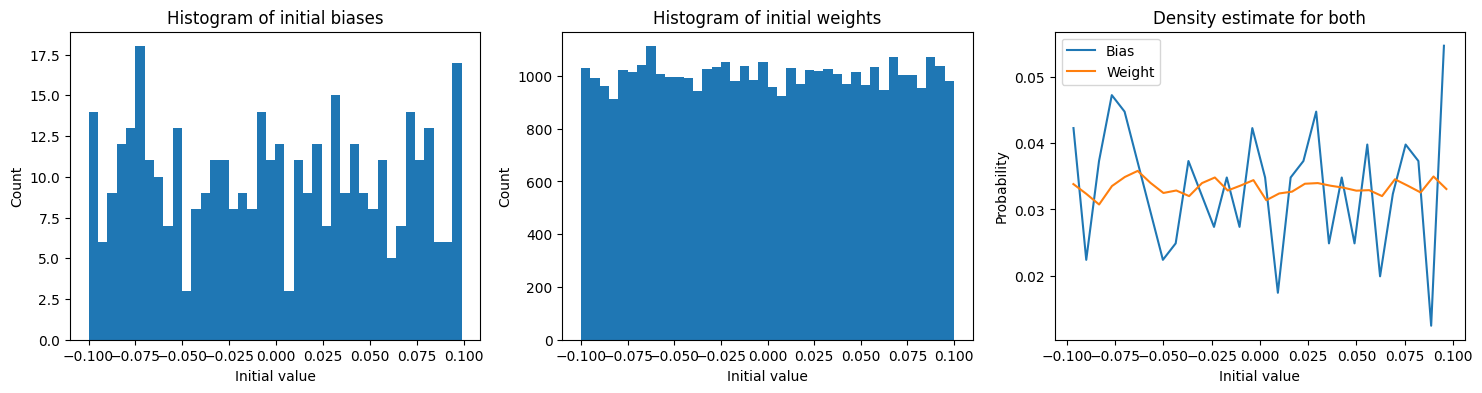

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].hist(all_biases, 40)
ax[0].set_title("Histogram of initial biases")

ax[1].hist(all_weights, 40)
ax[1].set_title("Histogram of initial weights")

yB, xB = np.histogram(all_biases, 30)
yW, xW = np.histogram(all_weights, 30)

ax[2].plot((xB[1:] + xB[:-1]) / 2, yB / np.sum(yB), label='Bias')
ax[2].plot((xW[1:] + xW[:-1]) / 2, yW / np.sum(yW), label='Weight')
ax[2].set_title("Density estimate for both")
ax[2].legend()

for i in range(3):
    ax[i].set_xlabel("Initial value")
    ax[i].set_ylabel('Count')

ax[2].set_ylabel('Probability')

plt.show()

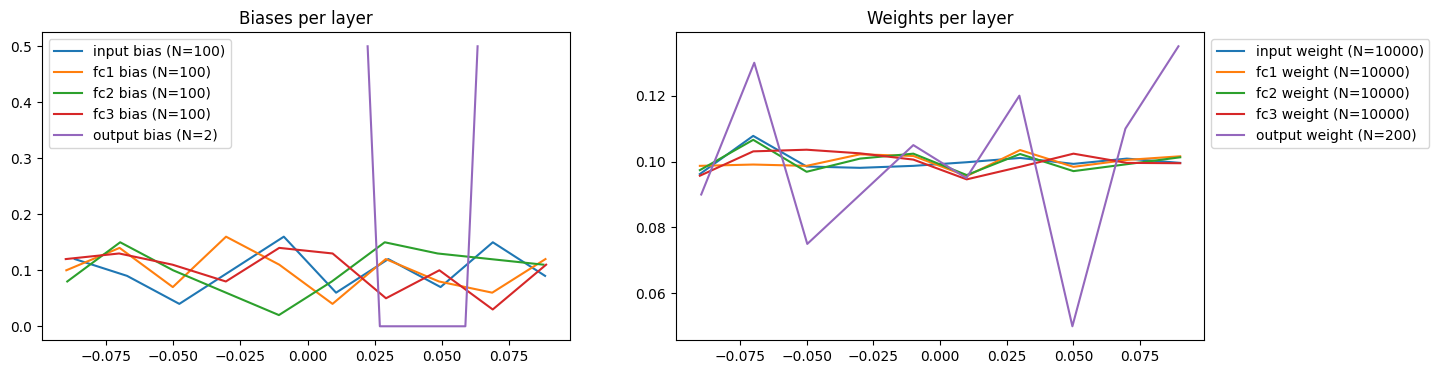

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

for p in net.named_parameters():
    data = p[1].data.numpy().flatten()
    y, x = np.histogram(data, 10)
    
    if 'bias' in p[0]:
        ax[0].plot((x[1:] + x[:-1]) / 2, y / np.sum(y), label="%s bias (N=%g)" %(p[0][:-5], len(data)))
    elif 'weight' in p[0]:
        ax[1].plot((x[1:] + x[:-1]) / 2, y / np.sum(y), label="%s weight (N=%g)" %(p[0][:-7], len(data)))
        
ax[0].set_title("Biases per layer")
ax[0].legend()
ax[1].set_title("Weights per layer")
ax[1].legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.show()

In [32]:
print(net.output.bias.data)

tensor([0.0201, 0.0656])


In [33]:
bias_range = [torch.min(net.fc1.bias.data).item(), torch.max(net.fc1.bias.data).item()]
bias_count = len(net.fc1.bias.data)
sigma = np.sqrt(1 / bias_count)

print(f"Theoretical sigma = ${sigma}")
print(f"Empirical range = ${bias_range}")

Theoretical sigma = $0.1
Empirical range = $[-0.09967644512653351, 0.09844529628753662]


In [34]:
net = Net()

for p in net.named_parameters():
    if 'weight' in p[0]:
        nn.init.xavier_normal_(p[1].data)

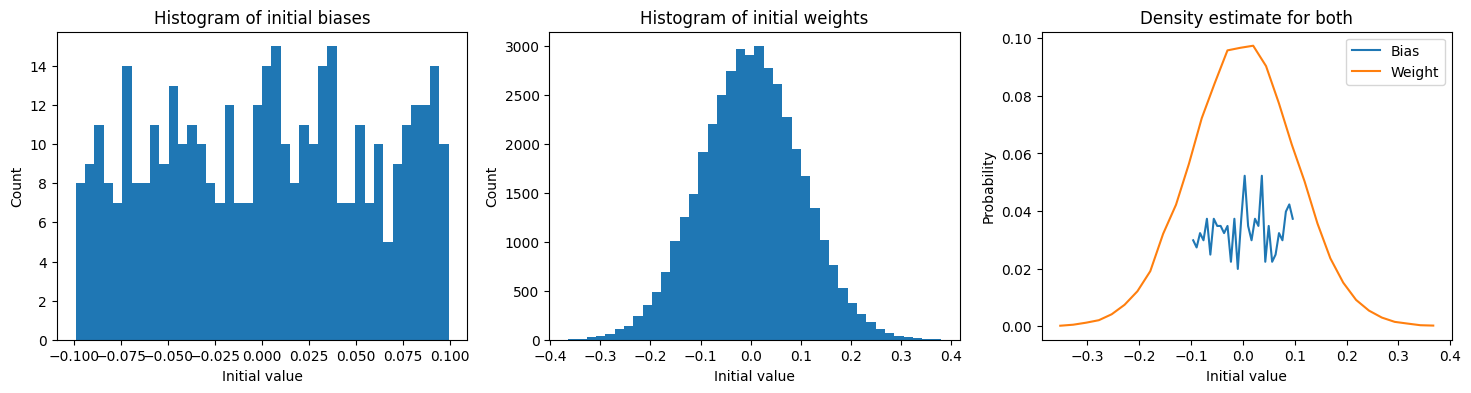

In [35]:
all_biases = np.array([])
all_weights = np.array([])

for p in net.named_parameters():
   if 'bias' in p[0]:
       all_biases = np.concatenate((all_biases, p[1].data.numpy().flatten()), axis=0)
   elif 'weight' in p[0]:
       all_weights = np.concatenate((all_weights, p[1].data.numpy().flatten()), axis=0)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].hist(all_biases, 40)
ax[0].set_title("Histogram of initial biases")

ax[1].hist(all_weights, 40)
ax[1].set_title("Histogram of initial weights")

yB, xB = np.histogram(all_biases, 30)
yW, xW = np.histogram(all_weights, 30)

ax[2].plot((xB[1:] + xB[:-1]) / 2, yB / np.sum(yB), label='Bias')
ax[2].plot((xW[1:] + xW[:-1]) / 2, yW / np.sum(yW), label='Weight')
ax[2].set_title("Density estimate for both")
ax[2].legend()

for i in range(3):
    ax[i].set_xlabel("Initial value")
    ax[i].set_ylabel('Count')

ax[2].set_ylabel('Probability')

plt.show()

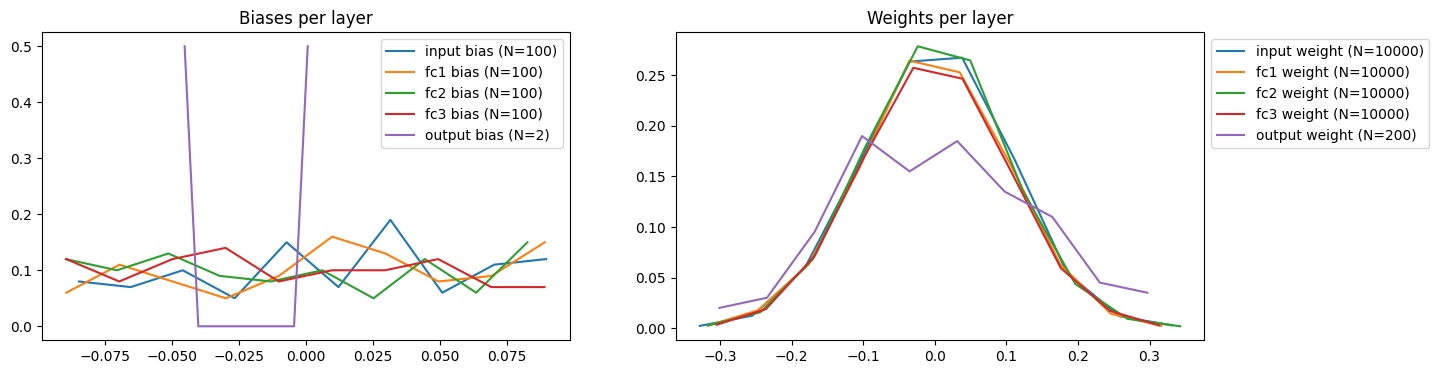

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

for p in net.named_parameters():
    data = p[1].data.numpy().flatten()
    y, x = np.histogram(data, 10)
    
    if 'bias' in p[0]:
        ax[0].plot((x[1:] + x[:-1]) / 2, y / np.sum(y), label="%s bias (N=%g)" %(p[0][:-5], len(data)))
    elif 'weight' in p[0]:
        ax[1].plot((x[1:] + x[:-1]) / 2, y / np.sum(y), label="%s weight (N=%g)" %(p[0][:-7], len(data)))
        
ax[0].set_title("Biases per layer")
ax[0].legend()
ax[1].set_title("Weights per layer")
ax[1].legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.show()

In [37]:
weight_var = torch.var(net.fc1.weight.data.flatten()).item()
weight_count = len(net.fc1.weight.data)

sigma = 2 / (weight_count + weight_count)

print(f"Theoretical sigma = ${sigma}")
print(f"Empirical variance = ${weight_var}")

Theoretical sigma = $0.01
Empirical variance = $0.010073008015751839


## CodeChallenge: Xavier vs. Kaiming

In [38]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
r = requests.get(url, timeout=30)

r.raise_for_status()

data = pd.read_csv(io.StringIO(r.text), sep=';')
data = data[data["total sulfur dioxide"] < 200]

In [39]:
cols_to_zscore = data.keys()
cols_to_zscore = cols_to_zscore.drop('quality')
data[cols_to_zscore] = data[cols_to_zscore].apply(stats.zscore)

data['boolQuality'] = 0
data.loc[data['quality'] > 5, 'boolQuality'] = 1
data_t = torch.tensor(data[cols_to_zscore].values).float()
labels = torch.tensor(data['boolQuality'].values).float()
labels = labels[:, None]

train_data, test_data, train_labels, test_labels = train_test_split(data_t, labels, test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [40]:
class AnnWine(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input = nn.Linear(11, 16)
        self.fc1 = nn.Linear(16, 32)
        self.fc2 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 1)
        
    def forward(self, x_param):
        x_local = F.relu(self.input(x_param))
        x_local = F.relu(self.fc1(x_local))
        x_local = F.relu(self.fc2(x_local))
        
        return self.output(x_local)

In [41]:
def train_model(model_param, train_loader_param, test_loader_param, xavier=False):
    for p_local in model_param.named_parameters():
        if 'weight' in p_local[0]:
            if xavier:
                nn.init.xavier_normal_(p_local[1].data)
            else:
                nn.init.kaiming_uniform_(p_local[1].data, nonlinearity='relu')
    
    loss_fun_local = nn.BCEWithLogitsLoss()
    optimizer_local = torch.optim.SGD(model_param.parameters(), lr=.01)
     
    train_accuracies_local = []
    test_accuracies_local = []
    losses_local = []
     
    for epoch in range(600):
        batch_accuracies = []
        batch_losses = []
         
        model_param.train()
         
        for X_local, y_local in train_loader_param:
            y_pred = model_param(X_local)
            loss = loss_fun_local(y_pred, y_local)
               
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
             
            correct_predictions = ((y_pred > 0) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())
            batch_losses.append(loss.item())
             
        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
    
        model_param.eval()
          
        X_local, y_local = next(iter(test_loader_param))
          
        with torch.no_grad():
            y_pred = model_param(X_local)
          
        correct_predictions = ((y_pred > 0) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local, losses_local

In [42]:
wine_net_xavier = AnnWine()

train_accuracies_xavier, test_accuracies_xavier, losses_xavier = train_model(wine_net_xavier, train_loader, test_loader, True)

In [43]:
wine_net_kaiming = AnnWine()

train_accuracies_kaiming, test_accuracies_kaiming, losses_kaiming = train_model(wine_net_kaiming, train_loader, test_loader)

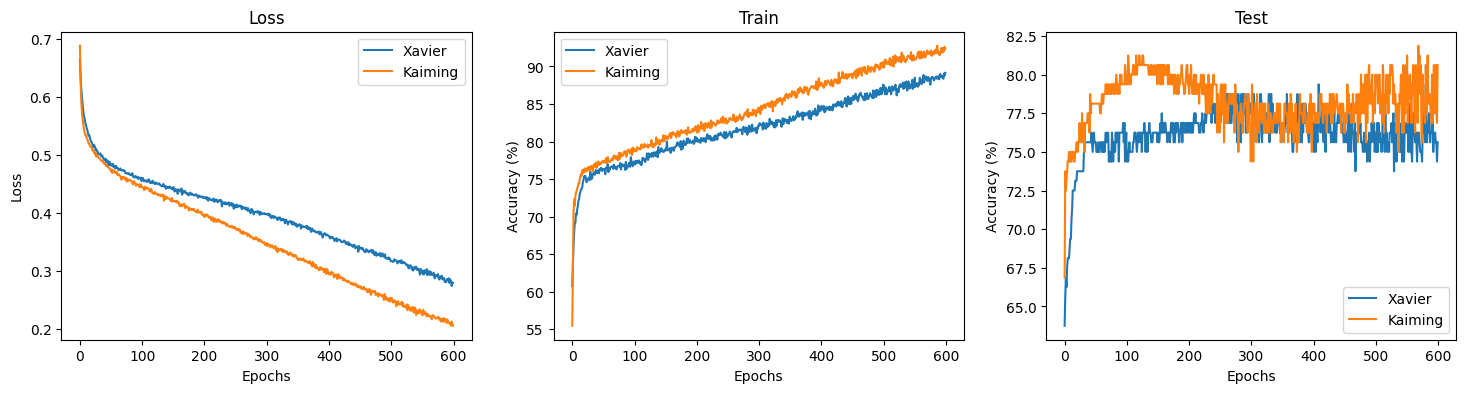

In [44]:
_, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].plot(losses_xavier, label='Xavier')
ax[0].plot(losses_kaiming, label='Kaiming')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(train_accuracies_xavier, label='Xavier')
ax[1].plot(train_accuracies_kaiming, label='Kaiming')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title('Train')
ax[1].legend()

ax[2].plot(test_accuracies_xavier, label='Xavier')
ax[2].plot(test_accuracies_kaiming, label='Kaiming')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Accuracy (%)")
ax[2].set_title('Test')
ax[2].legend()

plt.show()

In [45]:
train_accuracies_xavier, test_accuracies_xavier, losses_xavier = [], [], []
train_accuracies_kaiming, test_accuracies_kaiming, losses_kaiming = [], [], []
exp_nr = 10

for i in range(exp_nr):
    wine_net_xavier = AnnWine()
    train_acc_xavier, test_acc_xavier, loss_xavier = train_model(wine_net_xavier, train_loader, test_loader, True)
    
    train_accuracies_xavier.append(np.mean(train_acc_xavier[-5:]))
    test_accuracies_xavier.append(np.mean(test_acc_xavier[-5:]))
    losses_xavier.append(np.mean(loss_xavier[-5:]))
    
    wine_net_kaiming = AnnWine()
    train_acc_kaiming, test_acc_kaiming, loss_kaiming = train_model(wine_net_kaiming, train_loader, test_loader)
    
    train_accuracies_kaiming.append(np.mean(train_acc_kaiming[-5:]))
    test_accuracies_kaiming.append(np.mean(test_acc_kaiming[-5:]))
    losses_kaiming.append(np.mean(loss_kaiming[-5:]))

In [46]:
t_loss, p_loss = stats.ttest_ind(losses_xavier, losses_kaiming)
t_train, p_train = stats.ttest_ind(train_accuracies_xavier, train_accuracies_kaiming)
t_test, p_test = stats.ttest_ind(test_accuracies_xavier, test_accuracies_kaiming)

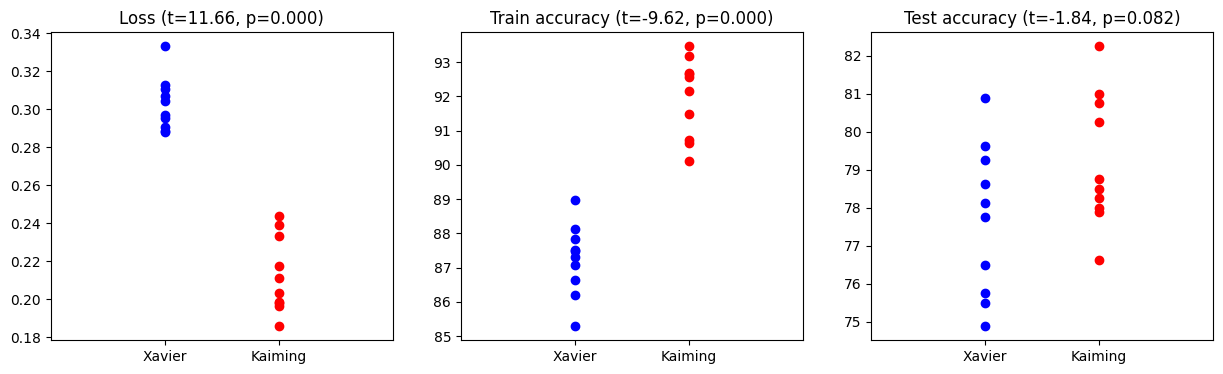

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(np.zeros(exp_nr), losses_xavier, 'bo')
ax[0].plot(np.ones(exp_nr), losses_kaiming, 'ro')
ax[0].set_xlim([-1, 2])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Xavier', 'Kaiming'])
ax[0].set_title("Loss (t=%.2f, p=%.3f)" %(t_loss, p_loss))

ax[1].plot(np.zeros(exp_nr), train_accuracies_xavier, 'bo')
ax[1].plot(np.ones(exp_nr), train_accuracies_kaiming, 'ro')
ax[1].set_xlim([-1, 2])
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Xavier', 'Kaiming'])
ax[1].set_title("Train accuracy (t=%.2f, p=%.3f)" %(t_train, p_train))

ax[2].plot(np.zeros(exp_nr), test_accuracies_xavier, 'bo')
ax[2].plot(np.ones(exp_nr), test_accuracies_kaiming, 'ro')
ax[2].set_xlim([-1, 2])
ax[2].set_xticks([0, 1])
ax[2].set_xticklabels(['Xavier', 'Kaiming'])
ax[2].set_title("Test accuracy (t=%.2f, p=%.3f)" %(t_test, p_test))

plt.show()

## CodeChallenge: Identically random weights

In [48]:
net = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

net_no_seed_weights = np.array([])
net_rs1a_weights = np.array([])
net_rs2_weights = np.array([])
net_rs1b_weights = np.array([])

In [49]:
net_no_seed = copy.deepcopy(net)

for p in net_no_seed.named_parameters():
    if 'weight' in p[0]:
        net_no_seed_weights = np.concatenate((net_no_seed_weights, p[1].data.numpy().flatten()), axis=0)

In [50]:
net_rs1a = copy.deepcopy(net)

torch.manual_seed(1)

for p in net_rs1a.named_parameters():
    if 'weight' in p[0]:
        nn.init.xavier_normal_(p[1].data)
        
        net_rs1a_weights = np.concatenate((net_rs1a_weights, p[1].data.numpy().flatten()), axis=0)

In [51]:
net_rs2 = copy.deepcopy(net)

torch.manual_seed(2)

for p in net_rs2.named_parameters():
    if 'weight' in p[0]:
        nn.init.xavier_normal_(p[1].data)
        
        net_rs2_weights = np.concatenate((net_rs2_weights, p[1].data.numpy().flatten()), axis=0)

In [52]:
net_rs1b = copy.deepcopy(net)

torch.manual_seed(1)

for p in net_rs1b.named_parameters():
    if 'weight' in p[0]:
        nn.init.xavier_normal_(p[1].data)
        
        net_rs1b_weights = np.concatenate((net_rs1b_weights, p[1].data.numpy().flatten()), axis=0)

In [53]:
vectorized_weight_indexes = np.arange(len(net_no_seed_weights))

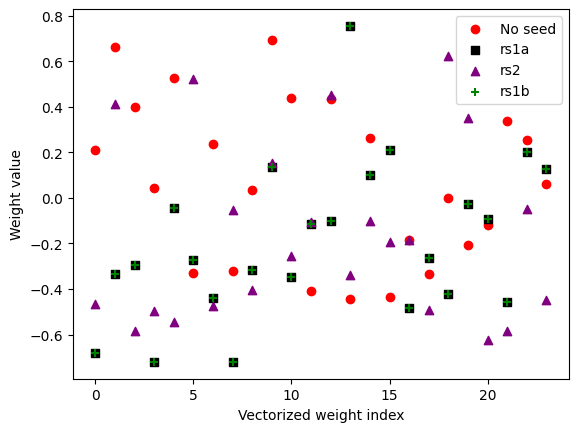

In [54]:
plt.scatter(vectorized_weight_indexes, net_no_seed_weights, marker='o', color='red', label="No seed")
plt.scatter(vectorized_weight_indexes, net_rs1a_weights, marker='s', color='black', label='rs1a')
plt.scatter(vectorized_weight_indexes, net_rs2_weights, marker='^', color='purple', label='rs2')
plt.scatter(vectorized_weight_indexes, net_rs1b_weights, marker='+', color='green', label='rs1b')
plt.xlabel("Vectorized weight index")
plt.ylabel("Weight value")
plt.legend()
plt.show()

## Freezing weights during learning

In [55]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

X = data[:, 1:]
y = data[:, 0]
X_norm = X / np.max(X)

X_tensor = torch.tensor(X_norm).float()
y_tensor = torch.tensor(y).long()

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=.1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [56]:
def create_model():
    class MnistNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input = nn.Linear(784, 64)
            self.fc1 = nn.Linear(64, 32)
            self.fc2 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 10)
            
        def forward(self, x_param):
            x_local = self.input(x_param)
            x_local = F.relu(x_local)
            x_local = self.fc1(x_local)
            x_local = F.relu(x_local)
            x_local = self.fc2(x_local)
            x_local = F.relu(x_local)

            return  self.output(x_local)
    
    mnist_net_local = MnistNet()
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.SGD(mnist_net_local.parameters(), lr=.001)
    
    return mnist_net_local, loss_function_local, optimizer_local

In [57]:
mnist_net = create_model()[0]

mnist_net.fc1.weight.requires_grad

True

In [58]:
for p in mnist_net.named_parameters():
    if 'input' not in p[0]:
        p[1].requires_grad = False
        
for p in mnist_net.named_parameters():
    print("Requires_grad status in layer %s: %s" %(p[0], p[1].requires_grad))

Requires_grad status in layer input.weight: True
Requires_grad status in layer input.bias: True
Requires_grad status in layer fc1.weight: False
Requires_grad status in layer fc1.bias: False
Requires_grad status in layer fc2.weight: False
Requires_grad status in layer fc2.bias: False
Requires_grad status in layer output.weight: False
Requires_grad status in layer output.bias: False


In [59]:
def train_model(mnist_net_local, loss_function_local, optimizer_local):
    epochs_nr = 100
    train_accuracies_local = []
    test_accuracies_local = []
     
    for epoch in range(epochs_nr):
        if epoch < (epochs_nr / 2):
            for p_local in mnist_net_local.named_parameters():
                if 'output' not in p_local[0]:
                    p_local[1].requires_grad = False
        else:
            for p_local in mnist_net_local.named_parameters():
                p_local[1].requires_grad = True
        
        batch_accuracies = []
         
        mnist_net_local.train()
         
        for X_local, y_local in train_loader:
            y_pred = mnist_net_local(X_local)
            loss = loss_function_local(y_pred, y_local)
               
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        mnist_net_local.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = mnist_net_local(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local

In [60]:
mnist_net, loss_function, optimizer = create_model()
train_acc, test_acc = train_model(mnist_net, loss_function, optimizer)

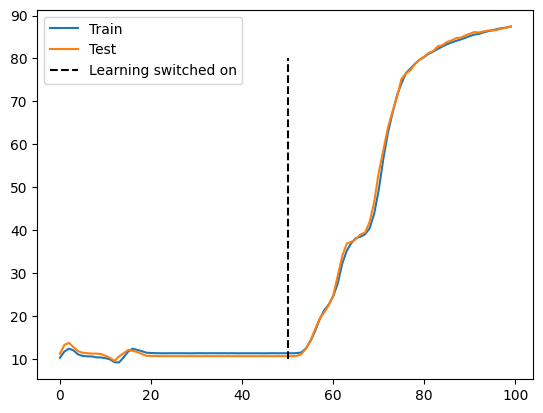

In [61]:
plt.plot(train_acc, label='Train')
plt.plot(test_acc, label='Test')
plt.plot([len(train_acc) / 2, len(train_acc) / 2], [10, 80], 'k--', label="Learning switched on")
plt.legend()
plt.show()

## Learning-related changes in weights

In [62]:
def train_model(mnist_net_local, loss_function_local, optimizer_local):
    epochs_nr = 60
    train_accuracies_local = []
    test_accuracies_local = []
    weight_change_local = np.zeros((epochs_nr, 4))
    weight_cond_local = np.zeros((epochs_nr, 4))
     
    for epoch in range(epochs_nr):
        pre_weights = []
        
        for p_local in mnist_net_local.named_parameters():
            if 'weight' in p_local[0]:
                pre_weights.append(copy.deepcopy(p_local[1].data.numpy()))
        
        batch_accuracies = []
         
        mnist_net_local.train()
         
        for X_local, y_local in train_loader:
            y_pred = mnist_net_local(X_local)
            loss = loss_function_local(y_pred, y_local)
               
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        mnist_net_local.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = mnist_net_local(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
    
        for i_local, p_local in enumerate(mnist_net_local.named_parameters()):
            if 'weight' in p_local[0]:
                weight_cond_local[epoch, int(i_local / 2)] = np.linalg.cond(p_local[1].data)
                weight_change_local[epoch, int(i_local / 2)] = np.linalg.norm(pre_weights[int(i_local / 2)] - p_local[1].data.numpy(), ord='fro')
    
    return train_accuracies_local, test_accuracies_local, weight_change_local, weight_cond_local

In [63]:
mnist_net, loss_function, optimizer = create_model()
train_acc, test_acc, weight_change, weight_cond = train_model(mnist_net, loss_function, optimizer)

In [64]:
layer_names = []

for i, p in enumerate(mnist_net.named_parameters()):
    if 'weight' in p[0]:
        layer_names.append(p[0][:-7])

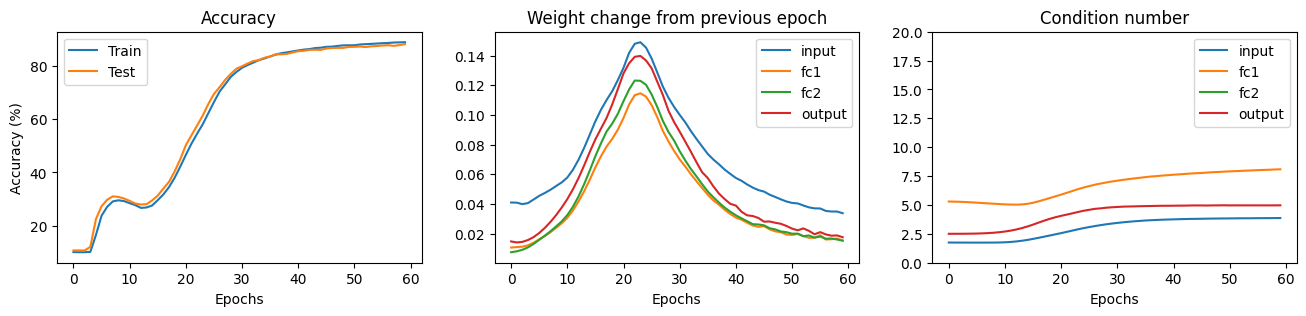

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3))

ax[0].plot(train_acc)
ax[0].plot(test_acc)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel("Accuracy (%)")
ax[0].set_title('Accuracy')
ax[0].legend(['Train','Test'])

ax[1].plot(weight_change)
ax[1].set_xlabel('Epochs')
ax[1].set_title("Weight change from previous epoch")
ax[1].legend(layer_names)

ax[2].plot(weight_cond)
ax[2].set_xlabel('Epochs')
ax[2].set_title("Condition number")
ax[2].legend(layer_names)
ax[2].set_ylim([0, 20])

plt.show()

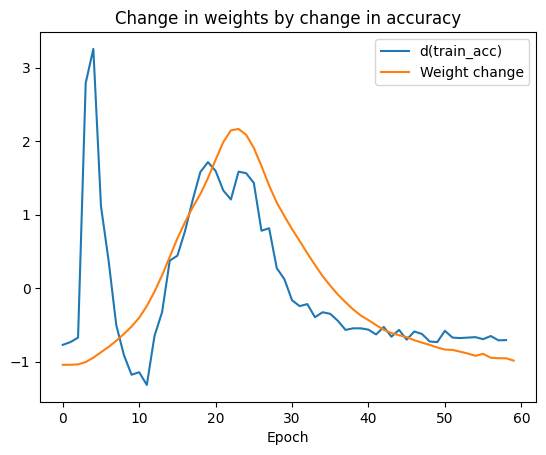

In [66]:
plt.plot(stats.zscore(np.diff(train_acc)), label='d(train_acc)')
plt.plot(stats.zscore(np.mean(weight_change, axis=1)), label="Weight change")
plt.xlabel('Epoch')
plt.title("Change in weights by change in accuracy")
plt.legend()
plt.show()